# Awareness Factor Investigation - Importance Computing

These are experimental codes:      
- Briefing the data
- Tuning optimal hyperparameter
- Visualize the performance of Models
- Visualize the importance
- Visualize and summerize impacts

In [1]:
%pwd

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article/MLD01e_Code'

In [2]:
%cd ..

/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article


/Users/lichao/opt/anaconda3/envs/ML/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 352)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 277)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=275)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].str.replace('Tarai', 'Terai')

In [12]:
eco_dummies = pd.get_dummies(df_all["EcoBelt"], prefix="EcoBelt").astype(int)
df_all = pd.concat([df_all, eco_dummies], axis=1)

In [13]:
prov_dummies = pd.get_dummies(df_all["Prov"], prefix="Prov").astype(int)
df_all = pd.concat([df_all, prov_dummies], axis=1)

In [14]:
df_all

EcoBelt          Prov  Rural_Dummy  Respon_Female  Respon_Age  \
PSU   HHLD                                                                   
101.0 1.0   Mountain         Koshi            1            1.0        49.0   
      2.0   Mountain         Koshi            1            0.0        55.0   
      3.0   Mountain         Koshi            1            1.0        46.0   
      4.0   Mountain         Koshi            1            0.0        78.0   
      5.0   Mountain         Koshi            1            0.0        70.0   
...              ...           ...          ...            ...         ...   
826.0 16.0     Terai  Sudurpaschim            0            0.0        47.0   
      17.0     Terai  Sudurpaschim            0            0.0        60.0   
      18.0     Terai  Sudurpaschim            0            1.0        47.0   
      19.0     Terai  Sudurpaschim            0            0.0        55.0   
      20.0     Terai  Sudurpaschim            0            0.0        45.0   

            LivingYear  Edu_UnderSLC  Edu_Certificate  Edu_Bachelor  \
PSU   HHLD                                                            
101.0 1.0         49.0             0                0             0   
      2.0         55.0             1                0             0   
      3.0         25.0             0                0             0   
      4.0         78.0             0                0             0   
      5.0         70.0             1                0             0   
...                ...           ...              ...           ...   
826.0 16.0        40.0             1                0             0   
      17.0        35.0             0                0             0   
      18.0        32.0             1                0             0   
      19.0        55.0             0                0             0   
      20.0        25.0             1                0             0   

            Edu_Master  ...  EcoBelt_Hill  EcoBelt_Mountain  EcoBelt_Terai  \
PSU   HHLD              ...                                                  
101.0 1.0            0  ...             0                 1              0   
      2.0            0  ...             0                 1              0   
      3.0            0  ...             0                 1              0   
      4.0            0  ...             0                 1              0   
      5.0            0  ...             0                 1              0   
...                ...  ...           ...               ...            ...   
826.0 16.0           0  ...             0                 0              1   
      17.0           0  ...             0                 0              1   
      18.0           0  ...             0                 0              1   
      19.0           0  ...             0                 0              1   
      20.0           0  ...             0                 0              1   

            Prov_Bagmati  Prov_Gandaki  Prov_Karnali  Prov_Koshi  \
PSU   HHLD                                                         
101.0 1.0              0             0             0           1   
      2.0              0             0             0           1   
      3.0              0             0             0           1   
      4.0              0             0             0           1   
      5.0              0             0             0           1   
...                  ...           ...           ...         ...   
826.0 16.0             0             0             0           0   
      17.0             0             0             0           0   
      18.0             0             0             0           0   
      19.0             0             0             0           0   
      20.0             0             0             0           0   

            Prov_Lumbini  Prov_Madhesh  Prov_Sudurpaschim  
PSU   HHLD                                                 
101.0 1.0              0             0                

### Revise Income Resources

In [15]:
df_all['IncomeResAgri_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 1).any(axis=1).astype(int)
df_all['IncomeResWage_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 2).any(axis=1).astype(int)
df_all['IncomeResNonAgriBusi_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 3).any(axis=1).astype(int)
df_all['IncomeResRemit_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 4).any(axis=1).astype(int)
df_all['IncomeResOthers_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 5).any(axis=1).astype(int)

In [16]:
df_all['ResidenceOwn_dummy'] = (df_all['Own_Resid'] == 1).astype(int)
df_all['ResidenceRent_dummy'] = (df_all['Own_Resid'] == 2).astype(int)
df_all['ResidenceInstitu_dummy'] = (df_all['Own_Resid'] == 3).astype(int)
df_all['ResidenceOthers_dummy'] = (df_all['Own_Resid'] == 4).astype(int)

In [17]:
df_all['ResidInfraPerman_dummy'] = (df_all['Resid_Type'] == 1).astype(int)
df_all['ResidInfraSemi_dummy'] = (df_all['Resid_Type'] == 2).astype(int)
df_all['ResidInfraKachchi_dummy'] = (df_all['Resid_Type'] == 3).astype(int)
df_all['ResidInfraOthers_dummy'] = (df_all['Resid_Type'] == 4).astype(int)

## Checking "ClimateChanged_Dummy"

### Dataset building

In [18]:
knowledge_prob_matrix = pd.read_parquet('MLD01e_Data/processed/Knowledge_probability.parquet')

In [19]:
knowledge_prob_matrix.index = df_all.index

In [20]:
df_all['Heard about Climate Change Probability'] = knowledge_prob_matrix['Heard about Climate Change Probability']

In [21]:
knowledge_prob_matrix = pd.read_parquet('MLD01e_Data/processed/Awareness_probability.parquet')

In [22]:
knowledge_prob_matrix.index = df_all.index

In [23]:
df_all['Climate Change Awareness Probability'] = knowledge_prob_matrix['Climate Change Awareness Probability']

In [24]:
df_inuse = df_all[['CommunityPartipationPast25',
                   'Climate Change Awareness Probability', 'Heard about Climate Change Probability', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',

                    # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT', 
                   
]]

In [25]:
variname_readable = {'Climate Change Awareness Probability':'Climate Change Awareness Probability',
                     'Heard about Climate Change Probability':'Heard about Climate Change Probability', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year",
                                         
                    }

In [26]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [27]:
variname_readable.update({'CommunityPartipationPast25': 'Community Participation in Past Dummy'})

In [28]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

## Hyperparameter

In [29]:
%ls MLD01e_Results

MLD01e_C01_KnowledgeFactorInvestigation.parquet*
MLD01e_C11_AwarenessFactorInvestigation_v1.parquet*
MLD01e_C21_ActionFactorInvestigation_SoilWaterConservationPast25_v1.parquet*
MLD01e_C31_ActionFactorInvestigation_RiskReductionPast25_v1.parquet*
MLD01e_C41_ActionFactorInvestigation_RoadImprovementPast25_v1.parquet*
MLD01e_C51_ActionFactorInvestigation_CommunityPartipationPast25_v1.parquet*
SummaryTable_ModelPerformance.xlsx
Table01_AllData_DataSummary.xlsx
Table01_DataSummaryForKnowledge_v1.xlsx
Table02_AccuracyTable_Knowledge_v1.xlsx
Table03_Importance_Knowledge_v1.xlsx
Table05_AccuracyTable_Logistic_Knowledge_v1.xlsx
Table11_DataSummaryAwareness_v1.xlsx
Table12_AccuracyTable_Awareness_v1.xlsx
Table12_Importance_Awareness_v1.xlsx
Table21_DataSummary_Action_SoilWaterConservationPast25_v1.xlsx
Table22_AccuracyTable_Action_SoilWaterConservationPast25_v1.xlsx
Table22_Importance_Action_SoilWaterConservationPast25_v1.xlsx
Table31_DataSummary_Action_RiskReductionPast25_v1.xlsx*
Table31_Data

In [30]:
cvres = pd.read_parquet('MLD01e_Results/MLD01e_C51_ActionFactorInvestigation_CommunityPartipationPast25_v1.parquet')

In [31]:
cvres.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
82,15.175066,0.304611,0.042798,0.001227,0.7,1000,1,16,0.01,0.9,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
198,8.448898,0.182579,0.041151,0.004953,1.0,1000,2,16,0.05,0.9,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
108,8.696622,0.241698,0.040778,0.005611,0.8,1000,1,16,0.05,1.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
138,10.758036,0.236315,0.052213,0.000626,0.8,2000,1,8,0.01,1.0,...,0.998943,0.999136,0.999039,0.999328,0.999424,0.999039,0.999232,0.998944,0.999155,0.000154
65,16.836320,0.245128,0.046934,0.008198,0.9,1000,1,16,0.01,0.9,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,1.574894,0.075195,0.024125,0.004889,0.9,500,5,4,0.01,0.9,...,0.828163,0.828066,0.825665,0.827298,0.824897,0.822880,0.824433,0.826930,0.825736,0.001715
182,0.664039,0.042791,0.016802,0.001188,1.0,200,10,4,0.01,0.7,...,0.787436,0.788301,0.785035,0.788109,0.784075,0.787148,0.789666,0.789282,0.787296,0.001798
31,0.696853,0.024050,0.016229,0.000938,1.0,200,5,4,0.01,0.9,...,0.781193,0.784171,0.777831,0.781961,0.779944,0.781289,0.782655,0.779965,0.781015,0.002259
133,0.679916,0.043223,0.020135,0.007670,0.8,200,5,4,0.01,1.0,...,0.783018,0.781961,0.778215,0.782634,0.779080,0.782634,0.781886,0.782559,0.781159,0.001662


In [32]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [33]:
params

{'colsample_bytree': 0.9,
 'learning_rate': 0.01,
 'max_depth': 16,
 'min_child_weight': 1,
 'n_estimators': 1000,
 'subsample': 0.7}

## 10-fold 10-epoch Estimation

In [34]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [35]:
y = df_inuse['Community Participation in Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Community Participation in Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [36]:
acc_lines = []
importances_df = []

for random_seed in range(42, 42*11, 42):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
    
    
        metrics = Metrics(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred).flatten()
        line  = [fold, random_seed] + metrics + list(cm)
        importances = clf.feature_importances_
    
        acc_lines.append(line)
        importances_df.append(importances)

fold: 1, random_seed:42
Accuracy: 0.8565254969749352
Precision: 0.7863013698630137
Recall   : 0.7653333333333333
F1-score : 0.7756756756756756
fold: 2, random_seed:42
Accuracy: 0.8357821953327571
Precision: 0.7427821522309711
Recall   : 0.7546666666666667
F1-score : 0.7486772486772487
fold: 3, random_seed:42
Accuracy: 0.8478824546240277
Precision: 0.7726027397260274
Recall   : 0.752
F1-score : 0.7621621621621621
fold: 4, random_seed:42
Accuracy: 0.8452895419187554
Precision: 0.7598944591029023
Recall   : 0.7659574468085106
F1-score : 0.7629139072847683
fold: 5, random_seed:42
Accuracy: 0.8634399308556612
Precision: 0.7898936170212766
Recall   : 0.7898936170212766
F1-score : 0.7898936170212766
fold: 6, random_seed:42
Accuracy: 0.8245462402765773
Precision: 0.7258485639686684
Recall   : 0.7393617021276596
F1-score : 0.7325428194993412
fold: 7, random_seed:42
Accuracy: 0.8340535868625756
Precision: 0.7513661202185792
Recall   : 0.7313829787234043
F1-score : 0.7412398921832885
fold: 8, ran

In [37]:
acc_df = pd.DataFrame(acc_lines)

In [38]:
acc_df.columns = ['fold', 'random_seed', 'acc', 'prec', 'recall', 'f1', 'TN', 'FP', 'FN', 'TP']

In [39]:
acc_df.to_excel('MLD01e_Results/Table52_AccuracyTable_CommunityPartipationPast25_v1.xlsx')

In [40]:
acc_df[['acc', 'prec', 'recall', 'f1']].mean(axis=0)

acc       0.843456
prec      0.762741
recall    0.752038
f1        0.757170
dtype: float64

In [41]:
import_df = pd.DataFrame(importances_df).T

In [42]:
import_df.index = X.columns

In [43]:
import_df['Mean_Importance'] = import_df.iloc[:,:100].mean(axis = 1)
import_df['Std_Importance'] = import_df.iloc[:,:100].std(axis = 1)

In [44]:
import_df['Mean_Importance']

Climate Change Awareness Probability      0.006381
Heard about Climate Change Probability    0.006776
Female Dummy                              0.005817
Age                                       0.005559
Years Living in Community                 0.005638
                                            ...   
Livestock Income                          0.005962
Non-agricultural Income                   0.009105
Business Income                           0.006667
Total Income                              0.006151
Survey Year                               0.339479
Name: Mean_Importance, Length: 71, dtype: float32

In [45]:
import_df.to_excel('MLD01e_Results/Table52_Importance_Action_CommunityPartipationPast25_v1.xlsx')

In [46]:
# Get importance values
importances = pd.Series(import_df['Mean_Importance'] , index=import_df.index)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

Survey Year                             0.339479
Having Organization Membership Dummy    0.091494
Having Agricultural Land Dummy          0.034880
Province Lumbibi Dummy                  0.029987
Having Other Vehicle Dummy              0.017308
Province Gandaki Dummy                  0.016051
Owned Residence Ownership Dummy         0.014390
Having Mobile Dummy                     0.012828
Province Karnali Dummy                  0.012366
Province Bagmati Dummy                  0.011437
Province Koshi Dummy                    0.011186
Having Telephone Dummy                  0.011149
EcoBelt Terai Dummy                     0.010978
EcoBelt Hill Dummy                      0.010868
Farm Mechanization Dummy                0.010396
Rented Residence Ownership Dummy        0.009939
Province Sudurpaschim Dummy             0.009498
Province Madhesh Dummy                  0.009341
EcoBelt Mountain Dummy                  0.009258
Non-agricultural Income                 0.009105
Name: Mean_Importanc

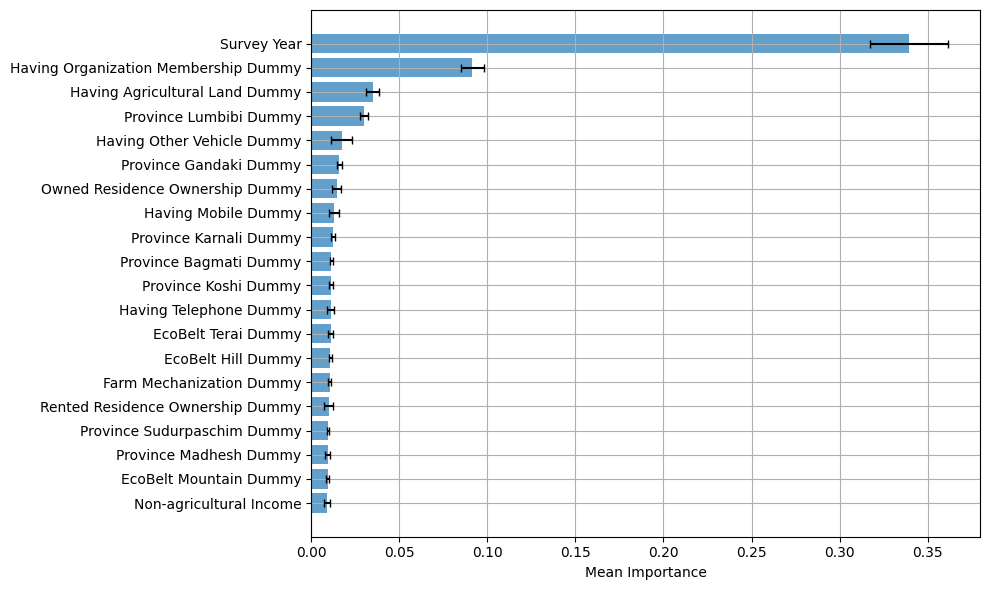

In [47]:
top20 = import_df.sort_values("Mean_Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(
    top20.index, 
    top20["Mean_Importance"], 
    xerr=top20["Std_Importance"] * 1.96, 
    align="center", 
    alpha=0.7, 
    ecolor="black", 
    capsize=3
)
plt.xlabel("Mean Importance")
plt.grid()
plt.gca().invert_yaxis()  # largest on top
plt.tight_layout()

plt.savefig("MLD01e_Figures/FigX_Action_CommunityPartipationPast25.jpg", dpi=300, bbox_inches="tight")

plt.show()